# Previsão de vendas de dezembro com regressão linear

Dezembro já está nos dados (3300). Para não cair em previsão circular, treino com Jan–Nov (meses 1..11) e uso dezembro como teste real, comparando previsão vs. valor verdadeiro. Modelo didático: a série é praticamente linear, então regressão linear simples basta.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 1. Dados

In [2]:
dados_vendas = {
    'mes': ['Janeiro','Fevereiro','Março','Abril','Maio','Junho',
            'Julho','Agosto','Setembro','Outubro','Novembro','Dezembro'],
    'vendas': [2000,2200,2300,2500,2600,2700,2800,2900,3000,3100,3200,3300]
}
df = pd.DataFrame(dados_vendas)
df

,mes,vendas
0,Janeiro,2000
1,Fevereiro,2200
2,Março,2300
3,Abril,2500
4,Maio,2600
5,Junho,2700
6,Julho,2800
7,Agosto,2900
8,Setembro,3000
9,Outubro,3100


## 2. Formatar

O modelo precisa de X numérico. Uso o índice do mês (1..12) como proxy do tempo.

In [3]:
df['mes_num'] = np.arange(1, len(df) + 1)
df

,mes,vendas,mes_num
0,Janeiro,2000,1
1,Fevereiro,2200,2
2,Março,2300,3
3,Abril,2500,4
4,Maio,2600,5
5,Junho,2700,6
6,Julho,2800,7
7,Agosto,2900,8
8,Setembro,3000,9
9,Outubro,3100,10


## 3. Treinar SEM dezembro (meses 1..11)

Dezembro fica de fora do treino para servir de teste.

In [4]:
treino = df[df['mes_num'] < 12]
X_treino = treino[['mes_num']]   # 2D, como o sklearn exige
y_treino = treino['vendas']

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
print(f"Inclinação: {modelo.coef_[0]:.1f} por mês | intercepto: {modelo.intercept_:.1f}")

Inclinação: 115.5 por mês | intercepto: 1970.9


## 4. Prever dezembro (mês 12) e comparar com o real

In [5]:
X_dez = pd.DataFrame({'mes_num': [12]})
pred_dez = modelo.predict(X_dez)[0]
real_dez = df.loc[df['mes_num'] == 12, 'vendas'].iloc[0]
print(f"Dezembro previsto: {pred_dez:.0f} | real: {real_dez} | erro: {pred_dez - real_dez:+.0f}")

Dezembro previsto: 3356 | real: 3300 | erro: +56


## 5. Histograma das vendas

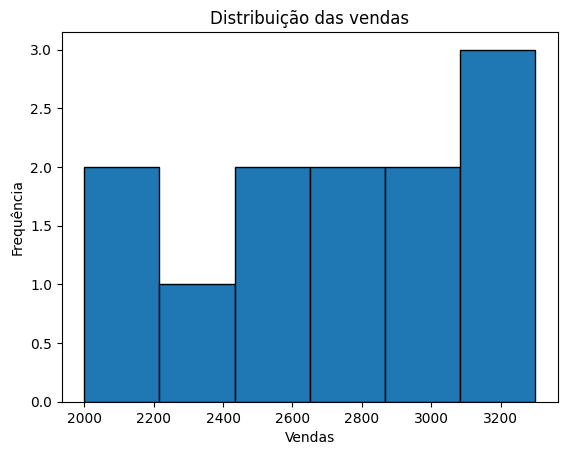

In [6]:
plt.figure()
plt.hist(df['vendas'], bins=6, edgecolor='black')
plt.xlabel('Vendas'); plt.ylabel('Frequência')
plt.title('Distribuição das vendas')
plt.show()

## 6. Scatter: mês x vendas + reta + previsão de dezembro

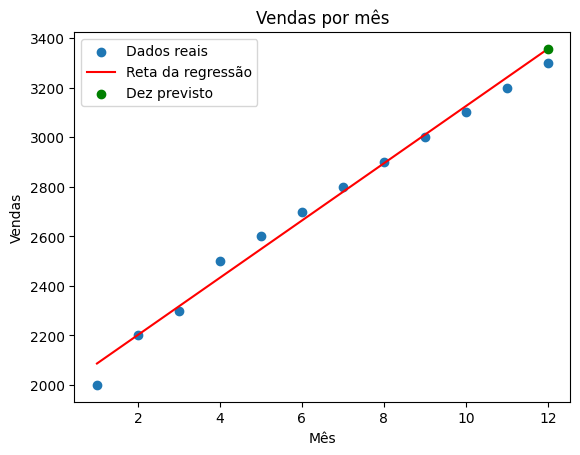

In [7]:
plt.figure()
plt.scatter(df['mes_num'], df['vendas'], label='Dados reais')
plt.plot(df['mes_num'], modelo.predict(df[['mes_num']]), color='red', label='Reta da regressão')
plt.scatter([12], [pred_dez], color='green', zorder=5, label='Dez previsto')
plt.xlabel('Mês'); plt.ylabel('Vendas')
plt.title('Vendas por mês'); plt.legend()
plt.show()